### Patch Antenna
We now apply a refined mesh for the patch antenna. Because the electromagnetic fields change rapidly near the metallic patch and the substrate edges, we increase the mesh density in these areas to ensure high simulation accuracy for resonance and radiation patterns.

In [1]:
import gmsh
import math

from palacetoolkit.plot_farfield import load_data, polar_plots, three_d_plot
from palacetoolkit.postpro import s_params
from palacetoolkit.simulation import generate_palace_config_from_entities
from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity, 
    run_entity_pipeline, 
    generate_3d_mesh, 
    create_graded_mesh
)


### Parameters:
- l : Patch length along x-axis, specified as a scalar in meters.
- w : Patch width along y-axis, specified as a scalar in meters.
- h : Patch height along z-axis, specified as a scalar in meters. 
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- l2 : Notch length along x-axis, specified as a scalar in meters. 
- w2 : Notch width along x-axis, specified as a scalar in meters. 
- w3 : Strip line width along y-axis, specified as a scalar in meters.
- airsphere_radius : Air sphere radius, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.
- eps_r: relative permittivity of the substrate
- loss_tan: loss tangent of the substrate
- port_impedance: characteristic impedance of the lumped port (Ohms)

In [2]:
# Patch
l: float = 0.030
w: float = 0.029

# Ground plane
l1: float = 0.06
w1: float = 0.06

# Notch
l2: float = 0.008
w2: float = 0.003

# Feed line
w3: float = 0.002

# Substrate
h: float = 0.0013

freq: float = 3.3
eps_r: float = 2.2
loss_tan: float = 0.0009
mu_r = 1.0
port_impedance: float = 50.0
wavelength = 3e8 / (freq * 1e9)

# Air sphere
airsphere_radius: float = wavelength

# Filename where the mesh is loadeds
filename = "patch_antenna.msh"

### Initialize the model

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry Construction
In this step, we build the physical structure of the patch antenna. We define the substrate, the metallic ground plane, and the antenna patch itself.

Patch Design: We combine the main patch and the feed line, including an inset to help with impedance matching.
Excitation: A lumped port is created and positioned to feed the antenna.
Domain Setup: We enclose the entire structure in an "air sphere," which defines the simulation region (the radiation space).
Finalizing: We use boolean operations (fragmenting) to ensure all components are properly connected and recognized as a single cohesive model by the solver.

In [4]:
substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)

# Ground plane
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

# Patch definition
main_patch = kernel.addRectangle(-l/2, -w/2, h, l, w)
inset = kernel.addRectangle(-l/2, -w2/2, h, l2, w2)

patch_dimtags, _ = kernel.cut(
    [(2, main_patch)], 
    [(2, inset)], 
    removeObject=True, removeTool=True
)
kernel.synchronize()

feed_length = (l1 - l)/2 + l2
feed_line = kernel.addRectangle(-l1/2, -w3/2, h, feed_length, w3)

# Our patch
top_conductor, _ = kernel.fuse(
    patch_dimtags, [(2, feed_line)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

# Gap bewteen the gropund plane and the bottom of the lumped port.
lumped_port = kernel.addRectangle(-l1/2, -w3/2, 0, h, w3)
kernel.rotate([(2, lumped_port)], -l1/2, 0, 0, 0, 1, 0, -math.pi/2)
kernel.synchronize()

def create_air_sphere(airsphere_radius: float) -> int:
    return kernel.addSphere(0.0, 0.0, 0.0, airsphere_radius)

air_sphere = create_air_sphere(airsphere_radius)
kernel.synchronize()

Info    : Cannot bind existing OpenCASCADE surface 8 to second tag 9
Info    : Could not preserve tag of 2D object 9 (->8)


### Entities definition and mesh refinement.

In [5]:
# Define the entities which later will become the physical groups.
entities = [
    Entity("air_sphere", dim = 3, mesh_order = 2, btype = "dielectric", tags = [air_sphere], loss_tan = 0.0, eps_r = 1.0, mu_r = 1.0),
    Entity("substrate", dim = 3, mesh_order = 1, btype = "dielectric", tags = [substrate], loss_tan = loss_tan, eps_r = eps_r, mu_r = mu_r),
    Entity("top_conductor", dim = 2, mesh_order= 1, btype = "pec", tags = [top_conductor[0][1]]),
    Entity("ground_plane", dim = 2, mesh_order = 1, btype = "pec", tags = [ground_plane]),
    Entity("lumped_port", dim = 2, mesh_order = 0, btype = "lumped_port", tags = [lumped_port], R = port_impedance, direction = '+Z', excitation = True)
]

# Boolean operations to guarantee a nice mesh, algo it returns the
# physical group map.
pg_map = run_entity_pipeline(entities)

# Refine near the top conductor and locally the lumped port
create_graded_mesh(  wavelength, 
                     ppw_near=100, 
                     ppw_far=5, 
                     transition_distance=wavelength/4,
                     set_as_background=True)

generate_3d_mesh(entities, output_file=filename, optimize=True)
gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
gmsh.write(filename)
gmsh.finalize()

  Physical group 'air_sphere' (dim=3): pg=1, tags=[2]
  Physical group 'substrate' (dim=3): pg=2, tags=[1]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[8]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[7]
  Physical group 'lumped_port' (dim=2): pg=5, tags=[9]
  Physical group 'air_sphere__None' (dim=2): pg=6, tags=[16]
  Physical group 'air_sphere__substrate' (dim=2): pg=7, tags=[10, 11, 13, 15, 14, 12]
  ignoring 3 curves from {'air_sphere__None'}
  global: 29 curves, SizeMin=0.0009
  ppw_near=100  ppw_far=5
  SizeMax=0.0182  transition=0.0227
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 45 (Line)
Info    : [ 10%] Meshing curve 46 (Line)
Info    : [ 10%] Meshing curve 47 (Line)
Info    : [ 10%] Meshing curve 48 (Line)
Info    : [ 20%] Meshing curve 49 (Line)
Info    : [ 20%] Meshing curve 50 (Line)
Info    : [ 20%] Meshing curve 51 (Line)
Info    : [ 30%] Meshing curve 52 (Line)
Info    : [ 30%] Meshing curve 53 (Line)
Info    : [ 30%] Meshing curve 54 (Line)


Info    : [ 80%] Meshing curve 69 (Line)
Info    : [ 80%] Meshing curve 70 (Line)
Info    : [ 90%] Meshing curve 71 (Line)
Info    : [ 90%] Meshing curve 72 (Line)


Info    : [100%] Meshing curve 74 (Circle)
Info    : [100%] Meshing curve 76 (Line)
Info    : Done meshing 1D (Wall 0.202703s, CPU 0.181473s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 7 (Plane, MeshAdapt)
Info    : [ 20%] Meshing surface 8 (Plane, MeshAdapt)
Info    : [ 30%] Meshing surface 9 (Plane, MeshAdapt)
Info    : [ 40%] Meshing surface 10 (Plane, MeshAdapt)
Info    : [ 50%] Meshing surface 11 (Plane, MeshAdapt)
Info    : [ 60%] Meshing surface 12 (Plane, MeshAdapt)
Info    : [ 70%] Meshing surface 13 (Plane, MeshAdapt)
Info    : [ 80%] Meshing surface 14 (Plane, MeshAdapt)
Info    : [ 90%] Meshing surface 15 (Plane, MeshAdapt)
Info    : [100%] Meshing surface 16 (Sphere, MeshAdapt)
Info    : Done meshing 2D (Wall 0.160928s, CPU 0.159229s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedrizing 2414 nodes...
Info    : Done tetrahedrizing 2422 nodes (Wall 0.0190293s, CPU 0.018094s)
Info    : Reconstructing mesh...


Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary


Info    : Done reconstructing mesh (Wall 0.0388202s, CPU 0.035774s)
Info    : Found volume 2
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 9.31919 (nodes removed 0 0)
Info    : It. 500 - 500 nodes created - worst tet radius 1.60424 (nodes removed 0 0)
Info    : It. 1000 - 999 nodes created - worst tet radius 1.18174 (nodes removed 0 1)
Info    : It. 1500 - 1499 nodes created - worst tet radius 1.01119 (nodes removed 0 1)
Info    : 3D refinement terminated (3957 nodes total):
Info    :  - 5 Delaunay cavities modified for star shapeness
Info    :  - 1 nodes could not be inserted
Info    :  - 22280 tetrahedra created in 0.0691906 sec. (322009 tets/s)
Info    : 0 node relocations
Info    : Done meshing 3D (Wall 0.148518s, CPU 0.145795s)
Info    : Optimizing mesh...
Info    : Optimizing volume 1
Info    : Optimization starts (volume = 4.68e-06) with worst = 0.0402918 / average = 0.682265:
Info    : 0.00 < quality < 0.10 :        10 elements
Info    : 0.10 < q

Info    : Total badness = 12200.3 
Info    : SwapImprove  


Info    : 416 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 11331.1 
Info    : Total badness = 10987.6 
Info    : CombineImprove 
Info    : 40 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 10602.3 
Info    : Total badness = 10567.5 
Info    : SplitImprove 
Info    : badmax = 22.9556 
Info    : 3 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 10582.5 
Info    : Total badness = 10575.1 
Info    : SwapImprove  
Info    : 93 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 10450 
Info    : Total badness = 10310.9 
Info    : CombineImprove 
Info    : 11 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 10211.8 
Info    : Total badness = 10200.4 
Info    : SplitImprove 
Info    : badmax = 15.0533 
Info    : 1 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 10204.9 
Info  

Info    : 18 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 30608.2 
Info    : Total badness = 27239.6 
Info    : SplitImprove 
Info    : badmax = 25.6358 
Info    : 1 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 27245.2 
Info    : Total badness = 26746.8 
Info    : SwapImprove  
Info    : 885 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 25149.5 
Info    : Total badness = 24545.3 
Info    : CombineImprove 
Info    : 5 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 24482 


Info    : Total badness = 24422 
Info    : SplitImprove 
Info    : badmax = 19.4012 
Info    : 0 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 24422 
Info    : Total badness = 24410.5 
Info    : SwapImprove  
Info    : 209 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 24233 
Info    : Total badness = 24084.8 
Info    : CombineImprove 
Info    : 0 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 24084.8 
Info    : Total badness = 24076.6 
Info    : SplitImprove 
Info    : badmax = 14.955 
Info    : 0 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 24076.6 
Info    : Total badness = 24075.5 
Info    : SwapImprove  


Info    : 80 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 24031.5 
Info    : Total badness = 23982.5 
Info    : Done optimizing mesh (Wall 0.757654s, CPU 0.761084s)
Info    : Writing 'patch_antenna.msh'...
Mesh saved to patch_antenna.msh
Info    : Done writing 'patch_antenna.msh'
  Nodes: 4182
  Elements: 28081
Info    : Writing 'patch_antenna.msh'...
Info    : Done writing 'patch_antenna.msh'


### Mesh visualization

In [6]:
view_mesh(filename, transparent_groups= "air_sphere__None")

Loading mesh file: patch_antenna.msh
Groups to render transparent: air_sphere__None



Mesh loaded successfully with 2 cell blocks
Found 4820 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port', 6: 'air_sphere__None', 7: 'air_sphere__substrate'}


### Simulation Configuration
We define the key parameters for the electromagnetic simulation here. These settings control the frequency sweep range, material properties (dielectric constant and loss tangent for the substrate), and solver-specific configurations like port impedance and mesh order.

- output_file  : output filename for the configuration JSON file
- freq_min : minimum frequency for the simulation (GHz)  
- freq_max: maximum frequency for the simulation (GHz)
- freq_step: frequency step for the simulation (GHz)
- solver_order: order of the finite element basis functions for the simulation (e.g., 1 for linear, 2 for quadratic)

In [7]:
output_file: str = "patch_antenna.json"
# Sweep de simulación 
freq_min: float = 2.5
freq_max: float = 4
freq_step: float = 0.025

solver_order: int = 2

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into a JSON configuration .

In [8]:
generate_palace_config_from_entities(entity_defs = [e.to_dict() for e in entities],
    pg_map = pg_map,
    mesh_file = filename,
    output_file = 'patch.config',
    freq_min = freq_min,
    freq_max = freq_max,
    freq_step = freq_step ,
    L0 = 1.0,
    solver_order = solver_order,
    absorbing_order = 2,
    farfield=True)

Palace config written to patch.config


{'Problem': {'Type': 'Driven', 'Verbose': 2, 'Output': 'postpro/patch'},
 'Model': {'Mesh': 'patch_antenna.msh', 'L0': 1.0, 'Refinement': {}},
 'Domains': {'Materials': [{'Attributes': [1],
    'Permeability': 1.0,
    'Permittivity': 1.0,
    'LossTan': 0.0},
   {'Attributes': [2],
    'Permeability': 1.0,
    'Permittivity': 2.2,
    'LossTan': 0.0009}]},
 'Boundaries': {'PEC': {'Attributes': [3, 4]},
  'Absorbing': {'Attributes': [6], 'Order': 2},
  'LumpedPort': [{'Index': 1,
    'Attributes': [5],
    'R': 50.0,
    'Excitation': True,
    'Direction': '+Z'}],
  'Postprocessing': {'FarField': {'Attributes': [6], 'NSample': 16000}}},
 'Solver': {'Order': 2,
  'Device': 'CPU',
  'Driven': {'MinFreq': 2.5,
   'MaxFreq': 4,
   'FreqStep': 0.025,
   'SaveStep': 5,
   'AdaptiveTol': 0.001},
  'Linear': {'Type': 'Default',
   'KSPType': 'GMRES',
   'Tol': 1e-08,
   'MaxIts': 500}}}

### Running Palace

In [9]:
from palacetoolkit.simulation import set_palace_path, run_palace
run_palace(config_file="patch.config", num_procs=16)

  Running: /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace -np 16 /home/martin/Desktop/PalaceToolkit/docs/examples/patch.config
>> /usr/bin/mpirun -n 16 /home/martin/.cache/palacetoolkit/runtime/palace-cpu-v0.1.2/bin/palace-x86_64.bin /home/martin/Desktop/PalaceToolkit/docs/examples/patch.config



_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (postpro/patch)
Git changeset ID: v0.16.1-51-g4f2e2d97
Running with 16 MPI processes, 1 OpenMP thread
Device configuration: omp,cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 690 duplicate vertices for interior boundaries in the mesh
Added 1841 duplicate boundary elements for interior boundaries in the mesh

Characteristic length and time scales:
 Lc = 1.818e-01 m, tc = 6.065e-01 ns
Finished partitioning mesh into 16 subdomains

Mesh curvature order: 1
Mesh bounding box:
 (Xmin, Ymin, Zmin) = (-9.062e-02, -9.058e-02, -9.091e-02) m
 (Xmax, Ymax, Zmax) = (+9.091e-02, +9.067e-02, +9.091e-02) m

Parallel Mesh Stats:

                minimum     average     maximum       total
 vertic


Configuring Robin absorbing BC (order 2) at attributes:
 6

Configuring Robin impedance BC for lumped ports at attributes:
 5: Rs = 7.692e+01 Ω/sq, n = (-1.0,+0.0,+0.0)

Configuring lumped port circuit properties:
 Index = 1: R = 5.000e+01 Ω

Configuring lumped port excitation source term at attributes:
 5: Index = 1

Configuring Dirichlet PEC BC at attributes:
 3-4

Computing adaptive fast frequency response for:
Excitation with index 1 has contributions from:
 Lumped port  1



Beginning PROM construction offline phase:
 61 points for frequency sweep over [2.500e+00, 4.000e+00] GHz

Assembling system matrices, number of global unknowns:
 H1 (p = 2): 34484, ND (p = 2): 153680, RT (p = 2): 209139
 Operator assembly level: Partial
 Mesh geometries:
  Tetrahedron: P = 20, Q = 14 (quadrature order = 4)

Assembling multigrid hierarchy:
 Level 0 (p = 1): 29612 unknowns
 Level 1 (p = 2): 153680 unknowns
 Level 0 (auxiliary) (p = 1): 4872 unknowns
 Level 1 (auxiliary) (p = 2): 34484 unknowns



  Residual norms for GMRES solve


...


It 58/61: ω/2π = 3.925e+00 GHz (total elapsed time = 1.54e+02 s)

 Sol. ||E|| = 2.941030e+01
 Field energy E (1.779e-10 J) + H (1.386e-10 J) = 3.165e-10 J
 S[1][1] = +1.170e-01-9.694e-01i, |S[1][1]| = -2.070e-01, arg(S[1][1]) = -8.312e+01



It 59/61: ω/2π = 3.950e+00 GHz (total elapsed time = 1.57e+02 s)

 Sol. ||E|| = 2.951470e+01
 Field energy E (1.783e-10 J) + H (1.390e-10 J) = 3.173e-10 J
 S[1][1] = +6.937e-02-9.743e-01i, |S[1][1]| = -2.045e-01, arg(S[1][1]) = -8.593e+01



It 60/61: ω/2π = 3.975e+00 GHz (total elapsed time = 1.60e+02 s)

 Sol. ||E|| = 2.962183e+01
 Field energy E (1.788e-10 J) + H (1.397e-10 J) = 3.185e-10 J
 S[1][1] = +2.143e-02-9.767e-01i, |S[1][1]| = -2.026e-01, arg(S[1][1]) = -8.874e+01



It 61/61: ω/2π = 4.000e+00 GHz (total elapsed time = 1.63e+02 s)

 Sol. ||E|| = 2.973053e+01
 Field energy E (1.794e-10 J) + H (1.405e-10 J) = 3.199e-10 J
 S[1][1] = -2.680e-02-9.767e-01i, |S[1][1]| = -2.012e-01, arg(S[1][1]) = -9.157e+01


 Wrote fields to disk (Paraview) at step 61

Completed 0 iterations of adaptive mesh refinement (AMR):
 Indicator norm = 2.233e-01, global unknowns = 153680
 Max. iterations = 0, tol. = 1.000e-02

Estimated peak per-rank memory usage is: Min. 154.9M, Max. 679.4M, Avg. 192.6M, Total 3.0G
Estimated peak per-node memory usage is: Min. 3.0G, Max. 3.0G, Avg. 3.0G, Total 3.0G

Elapsed Time Report (s)           Min.        Max.        Avg.
Initialization                   0.029       0.092       0.087
  Mesh Preprocessing             0.057       0.114       0.061
Operator Construction            0.445      58.736      55.089
Linear Solve                     6.040       6.160       6.078
  Setup                          6.832       6.833       6.833
  Preconditioner                42.645      42.889      42.850
  Coarse Solve                   3.954       4.100       3.978
PROM Construction                0.128       0.131       0.129
PROM Solve                       0.009       0.010       0.

### Post processing.

We want to see the S parameters, H plane, E plane and the radiation pattern.

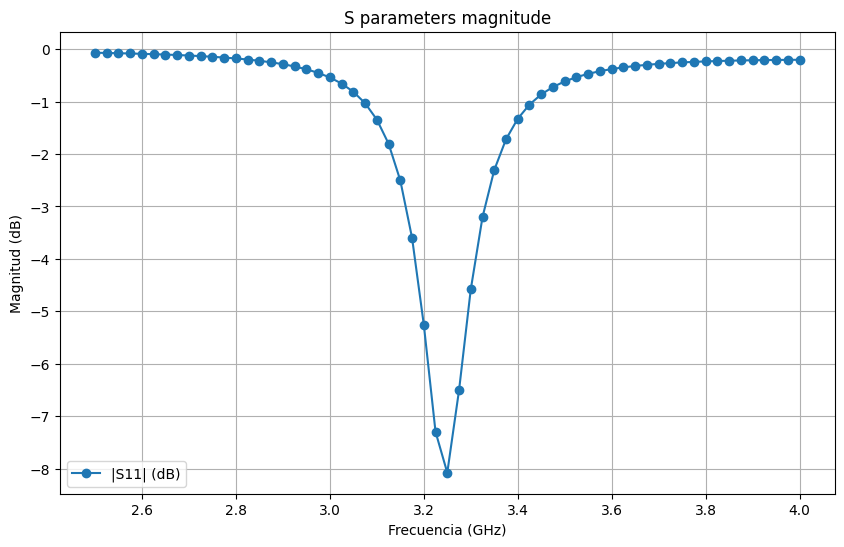

In [10]:
# S parameters. Return the frequency where the minimum is reached.
from pathlib import Path

notebook_dir = Path().resolve()
postpro_dir = notebook_dir / "postpro" / "patch"

f = s_params(str(postpro_dir / "port-S.csv"))

### Additional Field Visualizations at Resonant Frequency f

The next two views use the new VTU workflow:

- Surface-current-oriented view over antenna conductors.
- A z-slice in the air region above the patch to inspect forward propagation.

In [11]:
import importlib

import pyvista as pv
import palacetoolkit.postpro_vtu as postpro_vtu

postpro_vtu = importlib.reload(postpro_vtu)

# Prefer interactive backends in notebooks.
pv_backend = "static"
for candidate in ("trame", "client", "server"):
    try:
        pv.set_jupyter_backend(candidate)
        pv_backend = candidate
        break
    except Exception:
        pass

# Synchronize boundary/volume steps to the solved frequency f.
boundary_step, volume_step = postpro_vtu.resolve_synced_step_indices(
    postpro_dir,
    boundary_dataset="driven_boundary",
    volume_dataset="driven",
    timestep=float(f),
)

selector_ctx = postpro_vtu.build_selector_context("patch.config", pg_map)
conductors = ["top_conductor", "ground_plane"]
boundary_fields = postpro_vtu.load_boundary_field_data(
    postpro_dir,
    selector_ctx,
    entity_names=conductors,
    dataset_name="driven_boundary",
    step_index=boundary_step,
)

# Prefer explicit current-like vectors when present.
surface_vector_candidates = ["Jsurf_real", "J_real", "Jsurf", "J", "K_real", "K", "H_real", "E_real", "S"]
available_boundary = set(boundary_fields.point_arrays)
surface_vector = next((name for name in surface_vector_candidates if name in available_boundary), None)
if surface_vector is None:
    raise KeyError(f"No suitable surface vector field found. Available: {sorted(available_boundary)}")

pl_surface = postpro_vtu.plot_boundary_field(
    boundary_fields,
    vector_field=surface_vector,
    component="mag",
    cmap="plasma",
    log_scale=True,
    opacity=0.82,
    scalar_bar_title=f"|{surface_vector}| on conductors @ {float(f):.3f} GHz",
    show_edges=False,
    off_screen=False,
)

# Improve transparency sorting when available.
try:
    pl_surface.enable_depth_peeling()
except Exception:
    pass

# Keep a subtle wireframe so the surface crowding remains visible.
# pl_surface.add_mesh(
#     boundary_fields.mesh,
#     style="wireframe",
#     color="white",
#     line_width=1.0,
#     opacity=0.40,
#     lighting=True,
# )

# Orthographic top view with axis alignment.
top_view = True
if top_view:
    bounds = boundary_fields.mesh.bounds
    cx = 0.5 * (bounds[0] + bounds[1])
    cy = 0.5 * (bounds[2] + bounds[3])
    cz = 0.5 * (bounds[4] + bounds[5])
    span_xy = max(bounds[1] - bounds[0], bounds[3] - bounds[2])
    cam_dist = max(span_xy, 1e-9) * 3.0

    pl_surface.camera.position = (cx, cy, cz + cam_dist)
    pl_surface.camera.focal_point = (cx, cy, cz)
    pl_surface.camera.up = (0.0, 1.0, 0.0)
    pl_surface.enable_parallel_projection()
    pl_surface.camera.parallel_scale = 0.6 * span_xy
    pl_surface.add_bounding_box(color="black", line_width=1.0)

pl_surface.show(jupyter_backend=pv_backend)

Widget(value='<iframe src="http://localhost:45365/index.html?ui=P_0x72d6fa5d0830_0&reconnect=auto" class="pyvi…

In [12]:
from palacetoolkit.postpro_vtu import (
    activate_vector_component,
    extract_axis_slice,
    load_volume_field_data,
)

# Load volume data at the synchronized frequency step.
volume_fields = load_volume_field_data(
    postpro_dir,
    dataset_name="driven",
    step_index=volume_step,
)

# Slice slightly above the patch into the air region, along forward radiation direction (+z).
z_air_slice = h + 0.10 * wavelength
slice_mesh = extract_axis_slice(volume_fields, axis="z", value=float(z_air_slice))
scalar_name = activate_vector_component(slice_mesh, field_name="S", component="z", output_name="S_z")

# Combine mesh geometry + semi-transparent volume slice in one scene.
mesh_geom = pv.read(filename)
pl_air_slice = pv.Plotter(off_screen=False)
pl_air_slice.set_background("white")

# Keep a subtle wireframe so the surface crowding remains visible.
pl_air_slice.add_mesh(
    boundary_fields.mesh,
    style="wireframe",
    color="black",
    line_width=1.0,
    opacity=0.25,
    lighting=True,
)

# Overlay the slice with alpha transparency.
pl_air_slice.add_mesh(
    slice_mesh,
    scalars=scalar_name,
    cmap="viridis",
    opacity=0.62,
    show_edges=False,
    scalar_bar_args={"title": f"S_z in air slice @ z={z_air_slice:.4f} m, f={float(f):.3f} GHz"},
)

pl_air_slice.add_axes()
pl_air_slice.camera_position = "iso"
pl_air_slice.show(jupyter_backend=pv_backend)

Widget(value='<iframe src="http://localhost:45365/index.html?ui=P_0x72d6f8c1ab40_1&reconnect=auto" class="pyvi…

Columns found: ['f', 'theta', 'phi', 'r*Re{E_x}', 'r*Im{E_x}', 'r*Re{E_y}', 'r*Im{E_y}', 'r*Re{E_z}', 'r*Im{E_z}']
Processing frequency: 3.25 GHz  (16000 rows)
Extracting E-plane...
  E-plane phi~0°:   298 points
  E-plane phi~180°: 458 points
Extracting H-plane...
  H-plane theta~90°: 1922 points


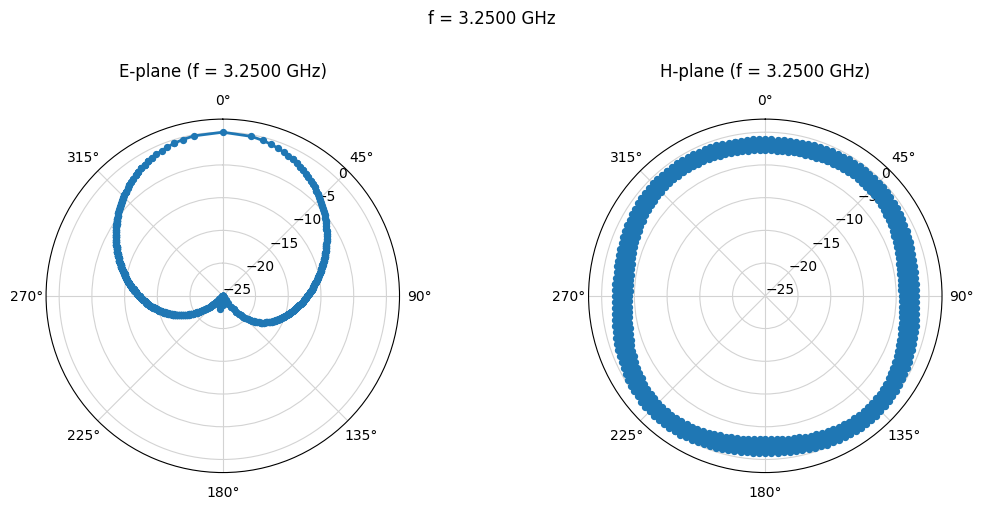

In [13]:
data, label = load_data(str(postpro_dir / "farfield-rE.csv"), f)
polar_plots(data, label)

In [14]:
# Radiation pattern.
three_d_plot(
        data, 
        label,
        n_theta           = 360,
        n_phi             = 720,
        n_smooth          = 100,
        taubin_pass_band  = 0.1,
    )

/home/martin/Desktop/PalaceToolkit/src/palacetoolkit/plot_farfield.py:207: PyVistaFutureWarning: The default value of `algorithm` for the filter
`StructuredGrid.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = grid.extract_surface()


Widget(value='<iframe src="http://localhost:45365/index.html?ui=P_0x72d6f88504a0_2&reconnect=auto" class="pyvi…